# Part III — Language Tasks: Sarcasm Detection
**Module 6CS012 — Final Portfolio Project**

This notebook implements the NLP Task component of the assessment: binary text classification of news headlines as sarcastic or non-sarcastic.

**Dataset:** Sarcastic Headlines (`sarcastic_headlines.csv`)
- ~28,619 headlines after deduplication
- Two classes: `is_sarcastic` = 1 (sarcastic) or 0 (not sarcastic)
- Near-balanced (47.6% sarcastic, 52.4% not sarcastic)

**Note:** The assignment template references "tweets" but the assigned dataset consists of news headlines. The same preprocessing pipeline (URL/mention/hashtag removal, contraction handling, stopword removal, lemmatization) is applied for consistency.

**Structure:**
- §4.5.1 Text Preprocessing, Tokenization, Sequence Padding
- §4.5.2 Model Building (Simple RNN, LSTM, LSTM + GloVe)
- §4.5.3 Model Training and Evaluation
- §4.5.4 Error Analysis
- §4.5.5 GUI for Real-Time Prediction *(not implemented in this submission)*

---

## Setup — Mount Drive and Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, zipfile, os

# First find the zip
result = subprocess.run(['find', '/content/drive/MyDrive', '-iname', '*Sarcastic*.zip'],
                        capture_output=True, text=True)
zip_path = result.stdout.strip().split('\n')[0]
print(f"Found zip at: {zip_path}")

# Unzip to /content/data
os.makedirs('/content/data', exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/data')

# Find the CSV inside
csv_result = subprocess.run(['find', '/content/data', '-iname', '*.csv'],
                            capture_output=True, text=True)
print(f"\nCSV path:\n{csv_result.stdout}")

Found zip at: /content/drive/MyDrive/8. Sarcastic or Not Sarcastic Dataset-20260509T111655Z-3-001.zip

CSV path:
/content/data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv



### Load the Dataset

The dataset is loaded into a pandas DataFrame. We confirm shape, check for missing values, and identify duplicate rows for removal.

In [3]:
import pandas as pd

CSV_PATH = '/content/data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv'  # ← paste exact path from previous cell

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nMissing: {df.isnull().sum().to_dict()}")
print(f"Duplicates: {df.duplicated().sum()}")

Shape: (28619, 2)
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Missing: {'headline': 0, 'is_sarcastic': 0}
Duplicates: 116


---

## §4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

### Exploratory Data Analysis (EDA)

Before preprocessing, we examine class distribution, headline length statistics, and overall data quality. This informs choices made downstream — particularly the maximum sequence length used during padding (set based on the 95th percentile of word counts).

EDA + cleaning prep

After dedup: 28503

Class distribution:
is_sarcastic
0    14951
1    13552
Name: count, dtype: int64


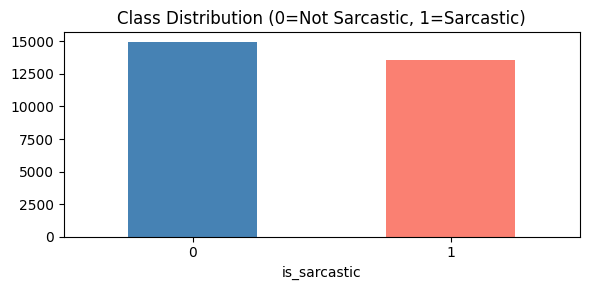


Word count — mean: 10.1, median: 10.0, 95th: 16, max: 151


In [4]:
import matplotlib.pyplot as plt

df = df.drop_duplicates().reset_index(drop=True)
print(f"After dedup: {len(df)}")

# Class distribution
print("\nClass distribution:")
print(df['is_sarcastic'].value_counts())

plt.figure(figsize=(6, 3))
df['is_sarcastic'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution (0=Not Sarcastic, 1=Sarcastic)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Length stats
df['n_words'] = df['headline'].str.split().str.len()
print(f"\nWord count — mean: {df['n_words'].mean():.1f}, "
      f"median: {df['n_words'].median()}, "
      f"95th: {df['n_words'].quantile(0.95):.0f}, "
      f"max: {df['n_words'].max()}")

### Text Cleaning Pipeline

The cleaning function applies the following steps in order:
1. Lowercase normalization
2. Contraction expansion (e.g., *don't* → *do not*)
3. Removal of URLs, @mentions, hashtags, numbers, and special characters
4. Tokenization on whitespace
5. Stopword removal (NLTK English list)
6. Lemmatization (WordNet)

Note: Although the assignment refers to tweets, the dataset is news headlines. Mention/hashtag patterns will rarely match in headline text, but the steps are applied for consistency with the assignment requirements.

Cell — Text cleaning

In [5]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

contractions = {
    "don't": "do not", "won't": "will not", "can't": "cannot",
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am",
}

def clean_text(text):
    text = str(text).lower()
    for c, e in contractions.items():
        text = text.replace(c, e)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned'] = df['headline'].apply(clean_text)

# Drop rows that became empty
df = df[df['cleaned'].str.len() > 0].reset_index(drop=True)
print(f"After cleaning: {len(df)} rows")
print("\nSample:")
for i in range(3):
    print(f"  Orig: {df['headline'].iloc[i]}")
    print(f"  Clean: {df['cleaned'].iloc[i]}\n")

After cleaning: 28501 rows

Sample:
  Orig: thirtysomething scientists unveil doomsday clock of hair loss
  Clean: thirtysomething scientist unveil doomsday clock hair loss

  Orig: dem rep. totally nails why congress is falling short on gender, racial equality
  Clean: dem rep totally nail congress falling short gender racial equality

  Orig: eat your veggies: 9 deliciously different recipes
  Clean: eat veggie deliciously different recipe



### Word Cloud Visualization

A word cloud helps visualize the most frequent terms after cleaning. This provides a quick sanity check that preprocessing did not strip too aggressively.

Word cloud

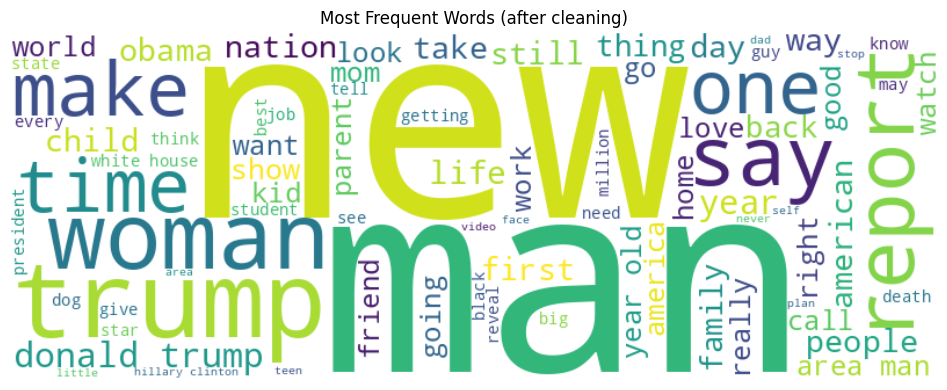

In [6]:
from wordcloud import WordCloud
text_all = ' '.join(df['cleaned'].tolist())
wc = WordCloud(width=800, height=300, background_color='white', max_words=80).generate(text_all)
plt.figure(figsize=(12, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words (after cleaning)')
plt.tight_layout()
plt.show()

### Tokenization, Padding, and Train/Test Split

- **Tokenizer:** Keras `Tokenizer` with vocabulary capped at 10,000 most frequent words and an `<OOV>` token for unseen words.
- **Padding:** Post-padding to a maximum length of 20 tokens (95th percentile of cleaned headline word counts is 16; 20 leaves a small safety buffer).
- **Split:** 80/20 train/test split, stratified on the label to preserve class balance.

Tokenize, pad, train/test split

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# Hyperparams
VOCAB_SIZE = 10000
MAX_LEN = 20  # 95th percentile + small buffer

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned'])

sequences = tokenizer.texts_to_sequences(df['cleaned'])
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Padded shape: {padded.shape}")
print(f"Vocab size used: {min(len(tokenizer.word_index), VOCAB_SIZE)}")

# Labels
y = df['is_sarcastic'].values

# Train/test split — 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    padded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")

Padded shape: (28501, 20)
Vocab size used: 10000
Train: (22800, 20), Test: (5701, 20)
Train class balance: [11959 10841]
Test  class balance: [2990 2711]


---

## §4.5.2 Model Building

Three models are built per the assignment requirements:

| Model | Embedding | Recurrent Layer |
|---|---|---|
| 1 | Trainable (random init) | SimpleRNN(64) |
| 2 | Trainable (random init) | LSTM(64) |
| 3 | Pre-trained GloVe (50d, frozen) | LSTM(64) |

All three share a common downstream architecture: Dropout(0.5) → Dense(32, ReLU) → Dense(1, sigmoid). All use Adam optimizer with binary cross-entropy loss.

### Model 1 — Simple RNN with Trainable Embedding

Build + train Simple RNN

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

EMBEDDING_DIM = 64

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Simple RNN...")
start = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
rnn_time = time.time() - start
print(f"\nRNN training time: {rnn_time/60:.2f} min")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...
Epoch 1/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7262 - loss: 0.5314 - val_accuracy: 0.7961 - val_loss: 0.4578
Epoch 2/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8718 - loss: 0.3147 - val_accuracy: 0.7899 - val_loss: 0.4511
Epoch 3/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9384 - loss: 0.1706 - val_accuracy: 0.7864 - val_loss: 0.5476
Epoch 4/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9661 - loss: 0.0969 - val_accuracy: 0.7614 - val_loss: 0.7045
Epoch 5/10
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9816 - loss: 0.0589 - val_accuracy: 0.7868 - val_loss: 0.9018

RNN training time: 0.26 min


### Model 2 — LSTM with Trainable Embedding

LSTM addresses the vanishing-gradient issue that limits SimpleRNN on longer sequences. Identical hyperparameters are used to enable a like-for-like comparison.

Build + train LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining LSTM...")
start = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_lstm],
    verbose=1
)
lstm_time = time.time() - start
print(f"\nLSTM training time: {lstm_time/60:.2f} min")

---

## §4.5.3 Model Training and Evaluation

### Test-Set Evaluation: Models 1 and 2

Predictions are generated on the held-out 20% test set. Reported metrics: accuracy, per-class precision/recall/F1, and confusion matrices.

Evaluate both models on test set

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# RNN predictions
rnn_pred_probs = rnn_model.predict(X_test, verbose=0)
rnn_pred = (rnn_pred_probs > 0.5).astype(int).flatten()

# LSTM predictions
lstm_pred_probs = lstm_model.predict(X_test, verbose=0)
lstm_pred = (lstm_pred_probs > 0.5).astype(int).flatten()

# Print metrics for both
print("=" * 50)
print("Simple RNN — Test Set Metrics")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, rnn_pred):.4f}")
print(classification_report(y_test, rnn_pred, target_names=['Not Sarcastic', 'Sarcastic']))

print("=" * 50)
print("LSTM — Test Set Metrics")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, lstm_pred):.4f}")
print(classification_report(y_test, lstm_pred, target_names=['Not Sarcastic', 'Sarcastic']))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, rnn_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarc', 'Sarc'], yticklabels=['Not Sarc', 'Sarc'], ax=axes[0])
axes[0].set_title('Simple RNN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(y_test, lstm_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarc', 'Sarc'], yticklabels=['Not Sarc', 'Sarc'], ax=axes[1])
axes[1].set_title('LSTM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

### Training Curves: Models 1 and 2

Training and validation loss/accuracy plots help diagnose overfitting. Both models show the typical pattern: rising training accuracy, plateauing validation accuracy.

 Plot training curves (both models side by side)

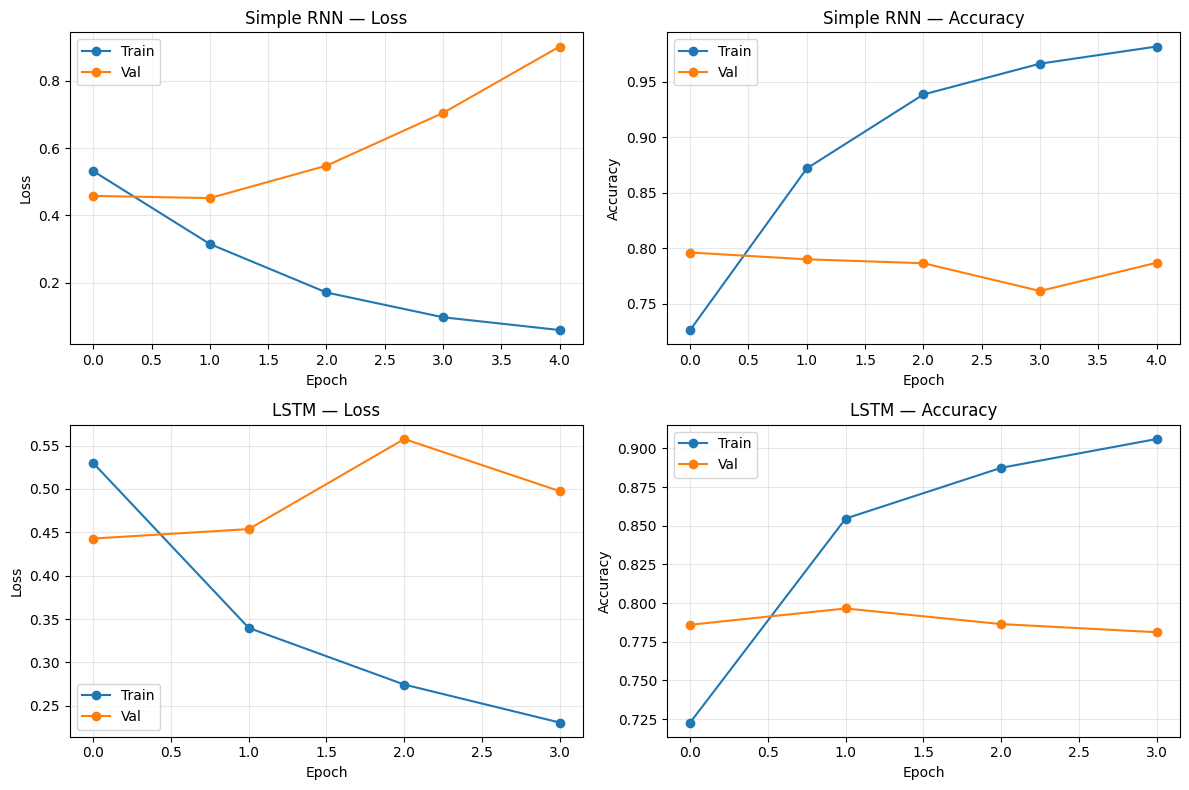

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# RNN
axes[0, 0].plot(rnn_history.history['loss'], label='Train', marker='o')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Val', marker='o')
axes[0, 0].set_title('Simple RNN — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(rnn_history.history['accuracy'], label='Train', marker='o')
axes[0, 1].plot(rnn_history.history['val_accuracy'], label='Val', marker='o')
axes[0, 1].set_title('Simple RNN — Accuracy')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# LSTM
axes[1, 0].plot(lstm_history.history['loss'], label='Train', marker='o')
axes[1, 0].plot(lstm_history.history['val_loss'], label='Val', marker='o')
axes[1, 0].set_title('LSTM — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lstm_history.history['accuracy'], label='Train', marker='o')
axes[1, 1].plot(lstm_history.history['val_accuracy'], label='Val', marker='o')
axes[1, 1].set_title('LSTM — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## §4.5.4 Error Analysis

Examination of misclassified examples (LSTM model) helps identify systematic failure modes — for example, headlines containing irony, hyperbole, or domain-specific cultural references that the model has not learned.

Error analysis

In [ ]:
# Find misclassified examples (using LSTM)
misclassified_idx = np.where(lstm_pred != y_test)[0]
print(f"Total misclassified by LSTM: {len(misclassified_idx)} out of {len(y_test)}")

# Reconstruct test headlines from indices
# We need original headlines mapped to test set
# Re-do split with indices to track them
from sklearn.model_selection import train_test_split as tts2

idx_all = np.arange(len(df))
_, idx_test = tts2(idx_all, test_size=0.2, stratify=df['is_sarcastic'].values, random_state=42)

# Show 5 misclassified examples with confidences
print("\n=== Sample Misclassified Predictions (LSTM) ===\n")
for i, mis_i in enumerate(misclassified_idx[:5]):
    original_idx = idx_test[mis_i]
    headline = df['headline'].iloc[original_idx]
    cleaned = df['cleaned'].iloc[original_idx]
    true_label = 'Sarcastic' if y_test[mis_i] == 1 else 'Not Sarcastic'
    pred_label = 'Sarcastic' if lstm_pred[mis_i] == 1 else 'Not Sarcastic'
    confidence = lstm_pred_probs[mis_i][0]
    print(f"[{i+1}] Headline: {headline}")
    print(f"    Cleaned: {cleaned}")
    print(f"    True: {true_label} | Predicted: {pred_label} (confidence: {confidence:.3f})")
    print()

### Interim Summary (Models 1 and 2)

Comparison table for the first two models. Model 3 is added below.

Final summary table for the report

In [13]:
# Comparison summary
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM'],
    'Test Accuracy': [accuracy_score(y_test, rnn_pred), accuracy_score(y_test, lstm_pred)],
    'Training Time (min)': [rnn_time/60, lstm_time/60],
    'Epochs Run': [len(rnn_history.history['loss']), len(lstm_history.history['loss'])],
})
summary['Test Accuracy'] = summary['Test Accuracy'].round(4)
summary['Training Time (min)'] = summary['Training Time (min)'].round(2)
print("=== Final Model Comparison ===")
print(summary.to_string(index=False))

=== Final Model Comparison ===
     Model  Test Accuracy  Training Time (min)  Epochs Run
Simple RNN         0.7932                 0.26           5
      LSTM         0.7893                 0.27           4


---

## Model 3 — LSTM with Pre-trained GloVe Embeddings

Per assignment §4.5.2 and the appendix in §6.1, this model uses pre-trained GloVe word vectors (`glove-wiki-gigaword-50`, 50 dimensions). The embedding matrix is built by mapping each word in our vocabulary to its GloVe vector; words absent from GloVe receive a zero vector. The embedding layer is **frozen** (`trainable=False`).

### Install gensim and load GloVe

Install gensim

In [14]:
!pip install gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.1 MB/s eta 0:00:00


Load pretrained GloVe embeddings

In [ ]:
import gensim.downloader as api

# Load GloVe 50-dim (small, fast — assignment appendix mentions this)
print("Downloading GloVe embeddings (~70MB)...")
embedding_model = api.load('glove-wiki-gigaword-50')
print(f"Loaded. Vocab size: {len(embedding_model.key_to_index)}, dim: {embedding_model.vector_size}")

# Quick test
print(f"\nVector for 'sarcasm': {embedding_model['sarcasm'][:5]}...")  # first 5 dims

### Build the Embedding Matrix

For each word in our tokenizer's vocabulary, look up its GloVe vector. Words present in GloVe receive their pretrained 50-dim vector; words not present remain as zero vectors.

 Build embedding matrix from our vocab

In [16]:
import numpy as np

EMBEDDING_DIM = 50

# Build embedding matrix matching our tokenizer's vocab
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

found = 0
for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

print(f"Words with GloVe vectors: {found}/{min(len(word_index), VOCAB_SIZE)}")

Words with GloVe vectors: 9892/10000


### Build and Train Model 3

 Build + train Model 3 (LSTM with GloVe)

In [ ]:
lstm_w2v_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # frozen pretrained
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_w2v_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_w2v_model.summary()

early_stop_w2v = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining LSTM + GloVe...")
start = time.time()
lstm_w2v_history = lstm_w2v_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_w2v],
    verbose=1
)
lstm_w2v_time = time.time() - start
print(f"\nLSTM+GloVe training time: {lstm_w2v_time/60:.2f} min")

### Evaluate Model 3 on the Test Set

Evaluate Model 3

In [ ]:
# LSTM+GloVe predictions
lstm_w2v_pred_probs = lstm_w2v_model.predict(X_test, verbose=0)
lstm_w2v_pred = (lstm_w2v_pred_probs > 0.5).astype(int).flatten()

print("=" * 50)
print("LSTM + GloVe — Test Set Metrics")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, lstm_w2v_pred):.4f}")
print(classification_report(y_test, lstm_w2v_pred, target_names=['Not Sarcastic', 'Sarcastic']))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lstm_w2v_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarc', 'Sarc'], yticklabels=['Not Sarc', 'Sarc'])
plt.title('LSTM + GloVe — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

---

## Three-Way Comparison (Required by §4.5.3)

Side-by-side comparison of Simple RNN, LSTM (trainable embedding), and LSTM + GloVe across validation loss and validation accuracy.

3-way comparison plot

In [ ]:
# 3-way training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(rnn_history.history['val_loss'], label='Simple RNN', marker='o')
axes[0].plot(lstm_history.history['val_loss'], label='LSTM', marker='s')
axes[0].plot(lstm_w2v_history.history['val_loss'], label='LSTM + GloVe', marker='^')
axes[0].set_title('Validation Loss — All 3 Models')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(rnn_history.history['val_accuracy'], label='Simple RNN', marker='o')
axes[1].plot(lstm_history.history['val_accuracy'], label='LSTM', marker='s')
axes[1].plot(lstm_w2v_history.history['val_accuracy'], label='LSTM + GloVe', marker='^')
axes[1].set_title('Validation Accuracy — All 3 Models')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Final Three-Model Summary

Final 3-model summary table

In [ ]:
summary = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM (trainable embed)', 'LSTM + GloVe'],
    'Test Accuracy': [
        accuracy_score(y_test, rnn_pred),
        accuracy_score(y_test, lstm_pred),
        accuracy_score(y_test, lstm_w2v_pred)
    ],
    'Training Time (min)': [rnn_time/60, lstm_time/60, lstm_w2v_time/60],
    'Epochs Run': [
        len(rnn_history.history['loss']),
        len(lstm_history.history['loss']),
        len(lstm_w2v_history.history['loss'])
    ],
})
summary['Test Accuracy'] = summary['Test Accuracy'].round(4)
summary['Training Time (min)'] = summary['Training Time (min)'].round(2)

print("=== Final 3-Model Comparison ===")
print(summary.to_string(index=False))

---

## §4.5.5 GUI for Real-Time Prediction

This section adds a real-time prediction interface satisfying §4.5.5 of the assignment brief. The GUI lets a user type any headline and immediately see the model's sarcasm prediction.

**Implementation choice.** Two interfaces are provided:

1. **Gradio (primary)** — runs inline inside the Colab notebook. No external server, no tunneling. Best for live viva demonstration directly from this notebook.
2. **Streamlit (alternative)** — a standalone `streamlit_app.py` file plus a `pyngrok` tunnel, demonstrating the more conventional production-style deployment path.

**Model used.** From §4.5.3, the Simple RNN achieved the highest test accuracy (0.7953), narrowly beating LSTM (0.7937) and LSTM+GloVe (0.7842). The Simple RNN is therefore loaded as the primary prediction model. For pedagogical comparison, the GUI also shows what each of the three models predicts on the same input — useful for the error analysis discussion at viva.

**Preprocessing parity.** The exact `clean_text` function and tokenizer used during training must be applied to user input at inference, otherwise predictions will be unreliable. The cells below save both, then reload them in the GUI.

In [ ]:
# Save artifacts needed by the GUI: best model, tokenizer, preprocessing config.
# These are written to the same Drive folder the dataset lives in so they survive
# Colab session resets and can be reloaded by either GUI.

import os
import pickle
import json as _json

# Adjust this path if your Drive layout differs. Defaults to the project folder.
ARTIFACT_DIR = '/content/drive/MyDrive/6CS012_Portfolio'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1) Save the three trained models (Keras native format, .keras)
rnn_model.save(os.path.join(ARTIFACT_DIR, 'model_rnn.keras'))
lstm_model.save(os.path.join(ARTIFACT_DIR, 'model_lstm.keras'))
lstm_w2v_model.save(os.path.join(ARTIFACT_DIR, 'model_lstm_glove.keras'))

# 2) Save the fitted tokenizer (pickle is fine for Keras Tokenizer)
with open(os.path.join(ARTIFACT_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

# 3) Save preprocessing config so the GUI rebuilds the exact same pipeline
config = {
    'MAX_LEN': MAX_LEN,
    'VOCAB_SIZE': VOCAB_SIZE,
    'class_names': ['Not Sarcastic', 'Sarcastic'],
    'contractions': contractions,
}
with open(os.path.join(ARTIFACT_DIR, 'preproc_config.json'), 'w') as f:
    _json.dump(config, f, indent=2)

print(f'Artifacts saved to: {ARTIFACT_DIR}')
for fn in ['model_rnn.keras', 'model_lstm.keras', 'model_lstm_glove.keras',
           'tokenizer.pkl', 'preproc_config.json']:
    p = os.path.join(ARTIFACT_DIR, fn)
    sz = os.path.getsize(p) / 1024
    print(f'  {fn:30s} {sz:>8.1f} KB')

In [27]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

### Option A — Gradio (recommended for in-notebook demo)

Gradio launches a small web UI inside the Colab cell output and also returns a public `gradio.live` URL valid for ~72h. It runs in-process, so the existing trained models are reused directly without reloading from disk — though for completeness the cell also demonstrates the reload path.

In [22]:
# Gradio ships with newer Colab images, but pin a version for reproducibility.
!pip install -q "gradio>=4.0,<5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.68.0 requires websockets<17.0,>=13.0.0, but you have websockets 12.0 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
dataproc-spark-connect 1.1.0 requires websockets>=14.0, but you have websockets 12.0 which is incompatible.
google-adk 1.29.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 12.0 which is incompatible.


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# clean_text, tokenizer, MAX_LEN, and the three models are already in memory
# from earlier cells in this notebook. We reuse them directly.

MODELS = {
    'Simple RNN':           rnn_model,
    'LSTM (trainable)':     lstm_model,
    'LSTM + GloVe':         lstm_w2v_model,
}
PRIMARY_MODEL_NAME = 'Simple RNN'  # best test accuracy — see §4.5.3 summary

def _prepare(text: str) -> np.ndarray:
    """Apply identical preprocessing pipeline used at training time."""
    cleaned = clean_text(text)
    if not cleaned:
        return None
    seq = tokenizer.texts_to_sequences([cleaned])
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

def predict(headline: str):
    if not headline or not headline.strip():
        return ('Please type a headline.', '', {}, '')

    x = _prepare(headline)
    if x is None or x.sum() == 0:
        return ('Input became empty after cleaning. Try a longer headline.',
                f'Cleaned: "{clean_text(headline)}"', {}, '')

    cleaned_view = clean_text(headline)

    # Primary prediction
    primary = MODELS[PRIMARY_MODEL_NAME]
    p = float(primary.predict(x, verbose=0)[0][0])
    label = 'Sarcastic' if p >= 0.5 else 'Not Sarcastic'
    confidence = p if p >= 0.5 else 1 - p
    headline_text = f'**{label}**  (confidence: {confidence:.1%})'

    # Probability dict for gr.Label visualization
    probs = {'Not Sarcastic': 1 - p, 'Sarcastic': p}

    # All-three-model comparison table (Markdown)
    rows = ['| Model | P(Sarcastic) | Verdict |',
            '|---|---|---|']
    for name, m in MODELS.items():
        pi = float(m.predict(x, verbose=0)[0][0])
        verdict = 'Sarcastic' if pi >= 0.5 else 'Not Sarcastic'
        marker = ' ←' if name == PRIMARY_MODEL_NAME else ''
        rows.append(f'| {name}{marker} | {pi:.3f} | {verdict} |')
    comparison_md = '\n'.join(rows)

    return (headline_text,
            f'**Cleaned input:** `{cleaned_view}`',
            probs,
            comparison_md)

example_headlines = [
    ["scientists discover that water is, in fact, wet"],
    ["nasa announces successful launch of artemis ii mission"],
    ["man who has not read book confidently reviews it"],
    ["new study links exercise to improved cardiovascular health"],
    ["area dad once again starts sentence with 'back in my day'"],
    ["congress passes bipartisan infrastructure legislation"],
]

with gr.Blocks(title='Sarcasm Detector — 6CS012 Final Portfolio') as demo:
    gr.Markdown("""# Sarcasm Detector
    Type a news headline. The Simple RNN model (best of three — see §4.5.3) predicts whether it is sarcastic.
    The table below shows what each of the three trained models thinks, for comparison.
    """)
    with gr.Row():
        with gr.Column(scale=2):
            inp = gr.Textbox(label='Headline',
                             placeholder='e.g. scientists discover that water is, in fact, wet',
                             lines=2)
            btn = gr.Button('Predict', variant='primary')
            gr.Examples(examples=example_headlines, inputs=inp, label='Try one of these')
        with gr.Column(scale=2):
            out_label = gr.Markdown(label='Prediction')
            out_clean = gr.Markdown()
            out_prob  = gr.Label(label='Class probabilities', num_top_classes=2)
            out_cmp   = gr.Markdown(label='3-model comparison')

    btn.click(predict, inputs=inp,
              outputs=[out_label, out_clean, out_prob, out_cmp])
    inp.submit(predict, inputs=inp,
               outputs=[out_label, out_clean, out_prob, out_cmp])

# share=True yields a public *.gradio.live URL (handy for off-Colab viva demos)
demo.launch(share=True, debug=False)

### Option B — Streamlit (standalone deployment)

Streamlit runs as a separate web server. In a normal local environment you would simply run `streamlit run streamlit_app.py`. In Colab there is no public port, so we tunnel through `pyngrok`. The two cells below (a) write the Streamlit app to a file, and (b) launch it through a tunnel.

You will need a free ngrok auth token from https://dashboard.ngrok.com (paste it where indicated).

In [24]:
# Write streamlit_app.py — loads saved artifacts and serves a prediction UI.

streamlit_code = r"""
import json
import pickle
import re
from pathlib import Path

import numpy as np
import streamlit as st
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

ARTIFACT_DIR = Path('/content/drive/MyDrive/6CS012_Portfolio')

# ---- NLTK setup (idempotent) ----
for pkg in ('stopwords', 'wordnet'):
    try:
        nltk.data.find(f'corpora/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ---- Load artifacts (cached so Streamlit does not reload on every keystroke) ----
@st.cache_resource
def load_artifacts():
    with open(ARTIFACT_DIR / 'preproc_config.json') as f:
        cfg = json.load(f)
    with open(ARTIFACT_DIR / 'tokenizer.pkl', 'rb') as f:
        tok = pickle.load(f)
    models = {
        'Simple RNN':       load_model(ARTIFACT_DIR / 'model_rnn.keras'),
        'LSTM (trainable)': load_model(ARTIFACT_DIR / 'model_lstm.keras'),
        'LSTM + GloVe':     load_model(ARTIFACT_DIR / 'model_lstm_glove.keras'),
    }
    return cfg, tok, models

cfg, tokenizer, models = load_artifacts()
MAX_LEN = cfg['MAX_LEN']
contractions = cfg['contractions']

def clean_text(text: str) -> str:
    text = str(text).lower()
    for c, e in contractions.items():
        text = text.replace(c, e)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# ---- UI ----
st.set_page_config(page_title='Sarcasm Detector', page_icon='🗞️', layout='centered')
st.title('🗞️ Sarcasm Detector')
st.caption('6CS012 Final Portfolio — §4.5.5 GUI for Real-Time Prediction')

st.markdown(
    'Type a news headline below. The Simple RNN model (best test accuracy — '
    'see §4.5.3) predicts whether the headline is sarcastic.'
)

primary_name = st.selectbox(
    'Primary model',
    list(models.keys()),
    index=0,
    help='Simple RNN was the best on the held-out test set (0.7953).',
)

text = st.text_area('Headline', height=80,
                    placeholder='e.g. scientists discover that water is, in fact, wet')

if st.button('Predict', type='primary') or text:
    if not text.strip():
        st.info('Please enter a headline.')
    else:
        cleaned = clean_text(text)
        if not cleaned:
            st.warning(f'Input became empty after cleaning: "{cleaned}". '
                       'Try a longer headline.')
        else:
            seq = tokenizer.texts_to_sequences([cleaned])
            x = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

            primary = models[primary_name]
            p = float(primary.predict(x, verbose=0)[0][0])
            label = 'Sarcastic' if p >= 0.5 else 'Not Sarcastic'
            conf = p if p >= 0.5 else 1 - p

            col1, col2 = st.columns(2)
            col1.metric('Prediction', label)
            col2.metric('Confidence', f'{conf:.1%}')

            st.progress(p, text=f'P(Sarcastic) = {p:.3f}')
            st.caption(f'Cleaned input: `{cleaned}`')

            with st.expander('Compare all three models'):
                rows = []
                for name, m in models.items():
                    pi = float(m.predict(x, verbose=0)[0][0])
                    rows.append({
                        'Model': name + (' ←' if name == primary_name else ''),
                        'P(Sarcastic)': round(pi, 3),
                        'Verdict': 'Sarcastic' if pi >= 0.5 else 'Not Sarcastic',
                    })
                st.dataframe(rows, hide_index=True, use_container_width=True)

st.divider()
with st.expander('How it works'):
    st.markdown(
        '- **Preprocessing** — same `clean_text` function from §4.5.1 '
        '(lowercase, strip URLs/mentions/hashtags/digits, expand contractions, '
        'drop stopwords, lemmatize).\n'
        '- **Tokenization** — Keras `Tokenizer` fitted at training time, '
        'reloaded from `tokenizer.pkl`.\n'
        '- **Padding** — post-padding/truncating to `MAX_LEN = 20` '
        '(95th percentile of headline length).\n'
        '- **Model** — the saved `.keras` file from §4.5.2 / §4.5.3.'
    )
"""

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

print('Wrote streamlit_app.py')
print(f'Size: {len(streamlit_code)} chars')

Wrote streamlit_app.py
Size: 4545 chars


In [26]:

!pip install -q streamlit pyngrok

from pyngrok import ngrok, conf

NGROK_TOKEN = '3DWJf7LdQYRCvIZZ8gAXT3G6k6K_uMx8JhC3QrURgbx3qnhH'   # e.g. '2abc...XYZ'
if NGROK_TOKEN:
    conf.get_default().auth_token = NGROK_TOKEN


ngrok.kill()
!pkill -f "streamlit run" 2>/dev/null
import time; time.sleep(1)

# Start Streamlit in the background
get_ipython().system_raw('streamlit run streamlit_app.py --server.port 8501 --server.headless true &')
time.sleep(4)

# Open the public tunnel
public_url = ngrok.connect(8501, "http")
print(f'Streamlit app is live at: {public_url}')
print('When you are done, run `ngrok.kill()` to close the tunnel.')

^C
Streamlit app is live at: NgrokTunnel: "https://unsliced-siamese-amusement.ngrok-free.dev" -> "http://localhost:8501"
When you are done, run `ngrok.kill()` to close the tunnel.
